### Wave Equation.

$$ \dfrac{\partial^2 u}{\partial t^2} = c^2\dfrac{\partial^2 u}{\partial x^2} $$

We want solve this wave-equation for the using a PINN.

Domain :

$$ t\in[0,4] $$
$$ x\in[0,1] $$

Boundary Conditions :

$$ u(0,t) = u(1,t) = 0, \forall\space t\in [0,4] $$

Initial Conditions :

$$ u(x,0) = \sin(\pi x) $$
$$ \dfrac{\partial u(x,0)}{\partial t} = 0 $$

### Analytic Solution.

The exact solution is given by :

$$ u(x,t) = \sin(\pi x)\cos(\pi t) $$

In [159]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

In [160]:
# parameters
c = 1.0

In [161]:
# defining the domain
N_x = 201
N_t = 201
x = torch.linspace(0.0, 1.0, N_x, requires_grad=True)
t = torch.linspace(0.0, 4.0, N_t, requires_grad=True)

x_mesh, t_mesh = torch.meshgrid(x,t)
# print(x_mesh,t_mesh)
input = torch.column_stack((x_mesh.flatten(),t_mesh.flatten()))
print(input.shape)

torch.Size([40401, 2])


In [162]:
# defining the model
model = nn.Sequential(
    nn.Linear(2,20),
    nn.Tanh(),
    nn.Linear(20,20),
    nn.Tanh(),
    nn.Linear(20,1)
)

In [163]:
# loss function
def Loss(model,x,t,x_mesh,t_mesh,input):
    u = model(input).reshape(N_x,N_t)
    
    # gradients
    # time gradients
    dudt = torch.autograd.grad(
        outputs = u,
        inputs = t_mesh,
        grad_outputs=torch.ones_like(u),
        create_graph=True
    )[0]

    d2udt2 = torch.autograd.grad(
        outputs = dudt,
        inputs = t_mesh,
        grad_outputs=torch.ones_like(dudt),
        create_graph=True
    )[0]

    # space gradients
    dudx = torch.autograd.grad(
        outputs = u,
        inputs = x_mesh,
        grad_outputs=torch.ones_like(u),
        create_graph=True
    )[0]

    d2udx2 = torch.autograd.grad(
        outputs = dudx,
        inputs = x_mesh,
        grad_outputs=torch.ones_like(dudx),
        create_graph=True
    )[0]

    # ode loss
    loss_ode = torch.mean((d2udt2 - c**2 * d2udx2)**2)

    # bc loss
    loss_bc = torch.mean(u[0,:]**2 + u[-1,:]**2)

    # ic loss
    loss_ic = torch.mean((u[:,0]-torch.sin(torch.pi*x))**2 + dudt[:,0]**2)

    return loss_ode + loss_ic + loss_bc

In [164]:
# optimizer
optim = torch.optim.Adam(model.parameters(), lr = 0.005)

In [165]:
# training the PINN
N_epoch = 50000
loss_arr = []
for epoch in range(N_epoch):
    loss = Loss(model, x, t, x_mesh, t_mesh, input)
    loss_arr.append(loss.item())
    loss.backward()
    optim.step()
    optim.zero_grad()

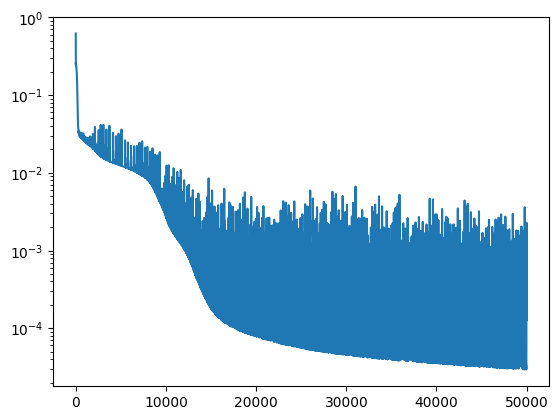

In [166]:
# loss visualisation
plt.semilogy(loss_arr)
plt.show()

In [167]:
# exact function
with torch.no_grad():
    u_exact = torch.sin(torch.pi * x_mesh) * torch.cos(torch.pi * t_mesh)
    u_nn = model(input).reshape(N_x,N_t)

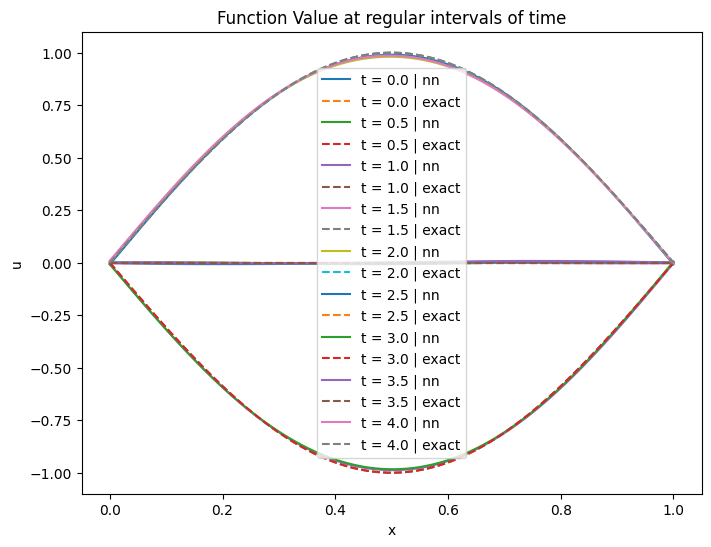

In [168]:
# visualising u(x,t) at fixed intervals of time
times = [0.0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0]
plt.figure(figsize = (8,6))

for time in times:
    index = int(time/(4.0/(N_t-1)))
    # print(time,index)
    plt.plot(x.detach().flatten(),u_nn[:,index].detach().flatten(),label = f't = {time} | nn')
    plt.plot(x.detach().flatten(),u_exact[:,index].detach().flatten(),label = f't = {time} | exact', ls = '--')
plt.legend()
plt.title("Function Value at regular intervals of time")
plt.xlabel("x")
plt.ylabel("u")
plt.show()

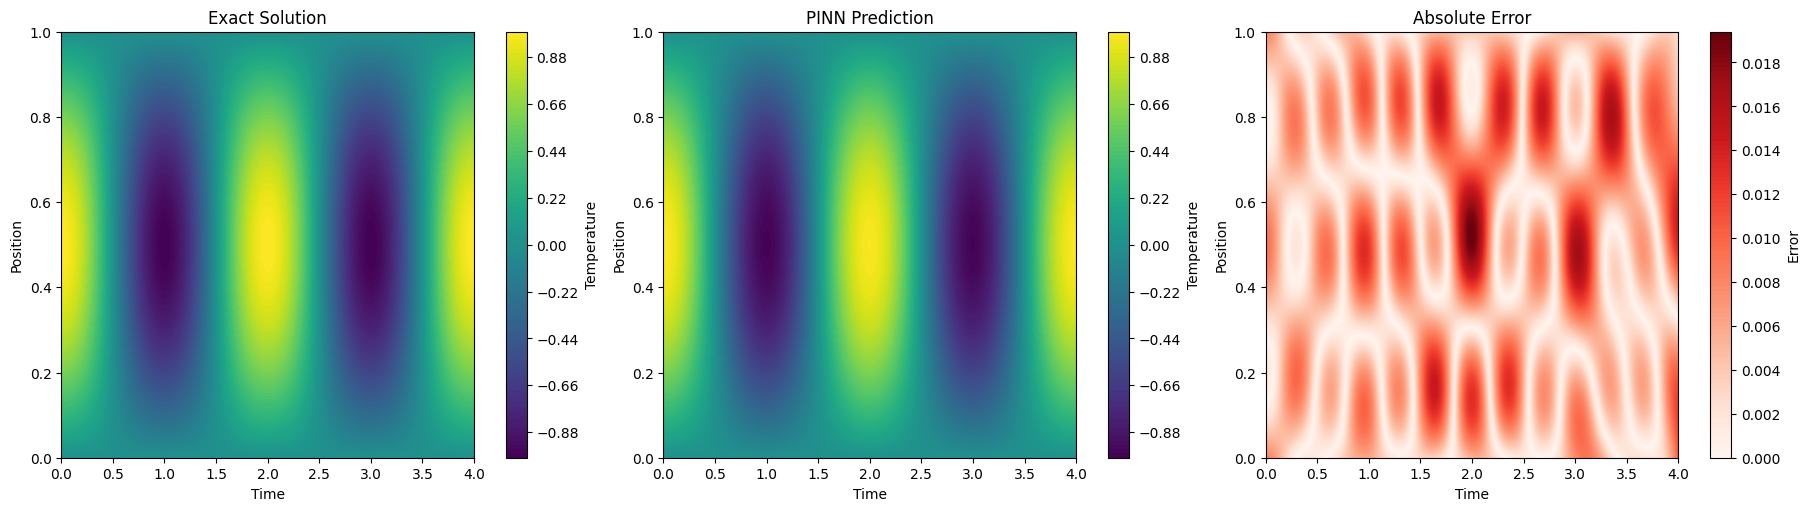

In [169]:
error = torch.abs(u_nn - u_exact)

fig, ax = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)

# Exact solution
c1 = ax[0].contourf(
    t_mesh.detach(),
    x_mesh.detach(),
    u_exact.detach(),
    levels=100,
    cmap="viridis"
)
ax[0].set_title("Exact Solution")
ax[0].set_xlabel("Time")
ax[0].set_ylabel("Position")
fig.colorbar(c1, ax=ax[0], label="Temperature")

# PINN prediction
c2 = ax[1].contourf(
    t_mesh.detach(),
    x_mesh.detach(),
    u_nn.detach(),
    levels=100,
    cmap="viridis"
)
ax[1].set_title("PINN Prediction")
ax[1].set_xlabel("Time")
ax[1].set_ylabel("Position")
fig.colorbar(c2, ax=ax[1], label="Temperature")

# Absolute error
c3 = ax[2].contourf(
    t_mesh.detach(),
    x_mesh.detach(),
    error.detach(),
    levels=100,
    cmap="Reds"
)
ax[2].set_title("Absolute Error")
ax[2].set_xlabel("Time")
ax[2].set_ylabel("Position")
fig.colorbar(c3, ax=ax[2], label="Error")

plt.show()